# BACE TAME Ablation (1 Seed)

Ziel: Ablation der non-fusion TAME Architektur auf BACE (DeepChem MolNet scaffold split) fuer einen Seed. Verglichen werden vier Branch-Kombinationen:
- ChebNet (nur Graph)
- ChebNet + Text (Graph+Text, 2-Branch MoE)
- ChebNet + RDKit Deskriptoren (Graph+Desc, 2-Branch MoE)
- TAME (Graph+Text+Desc, 3-Branch MoE)

Setup:
- Seed: 11
- Split: DeepChem scaffold split (predefined)
- Checkpoint: stage-1 ChebNet Encoder
- Backbone: h=128, K=3, L=3, set2set pooling
- Metriken: ROC-AUC, Accuracy, F1 (Threshold ueber Val-F1)


In [1]:
import sys
import random
from pathlib import Path
from contextlib import contextmanager
from dataclasses import dataclass

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import deepchem as dc

from sklearn.metrics import roc_auc_score, accuracy_score, f1_score

from rdkit import Chem, RDLogger
from rdkit.Chem import Descriptors

RDLogger.DisableLog("rdApp.warning")
RDLogger.DisableLog("rdApp.error")

here = Path.cwd().resolve()
workspace_root = next((p for p in [here, *here.parents] if (p / "models").exists()), here)
if str(workspace_root) not in sys.path:
    sys.path.insert(0, str(workspace_root))

from models.cheb_predictor import ChebPredictor, ChebPredictorConfig
from models.tame_predictor import TAMEPredictor, TAMEPredictorConfig
from models.core.graph_encoder import ChebNetEncoder
from models.core.pooling import create_pooling

from utils.embedding_cache import EfficientEmbeddingCache
from utils.batched_mol_graph import batch_graphs
from utils.molecular_graph import smiles_to_graph

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Workspace root: {workspace_root}")
print(f"Device: {device}")


No normalization for SPS. Feature removed!
No normalization for AvgIpc. Feature removed!
No normalization for NumAmideBonds. Feature removed!
No normalization for NumAtomStereoCenters. Feature removed!
No normalization for NumBridgeheadAtoms. Feature removed!
No normalization for NumHeterocycles. Feature removed!
No normalization for NumSpiroAtoms. Feature removed!
No normalization for NumUnspecifiedAtomStereoCenters. Feature removed!
No normalization for Phi. Feature removed!
Skipped loading some Tensorflow models, missing a dependency. No module named 'tensorflow'
Skipped loading modules with pytorch-geometric dependency, missing a dependency. No module named 'torch_geometric'
Skipped loading modules with transformers dependency. No module named 'transformers'
cannot import name 'HuggingFaceModel' from 'deepchem.models.torch_models' (/home/robert/Hiwi/TAME-MPP/molfusion2/.venv/lib/python3.12/site-packages/deepchem/models/torch_models/__init__.py)
Skipped loading modules with pytorch-

Workspace root: /home/robert/Hiwi/TAME-MPP/molfusion2
Device: cpu


In [2]:
SEEDS = [11, 22, 33, 44, 55]

CHECKPOINT_PATH = (
    workspace_root
    / "cache"
    / "chemeleon_pretraining"
    / "cheb_foundation_stage1__h128__L3__K3__pool-set2set__drop-0p2000__head-256__dim-1592__subset-600000.pt"
)

BACKBONE_ARCH = {
    "hidden_channels": 128,
    "K": 3,
    "num_layers": 3,
    "pool": "set2set",
    "set2set_processing_steps": 3,
}

CHEB_FIT_KWARGS = {
    "num_epochs": 140,
    "batch_size": 32,
    "learning_rate": 17e-4*0.02,
    "weight_decay": 6e-4,
    "patience": 20,
}

BIMODAL_FIT_KWARGS = {
    "num_epochs": 120,
    "batch_size": 32,
    "learning_rate": 17e-4*0.02,
    "weight_decay": 6e-4,
    "patience": 20,
}

TAME_FIT_KWARGS = dict(BIMODAL_FIT_KWARGS)

BIMODAL_MODEL_KWARGS = {
    "fusion_hidden_dim": 128,
    "projection_dropout": 0.25,
    "router_dropout": 0.5,
    "head_hidden_dim": 128,
    "head_dropout": 0.43,
}

DESCRIPTOR_PREPROCESS = {
    "winsorize_lower_q": 0.01,
    "winsorize_upper_q": 0.99,
    "standardize": True,
    "eps": 1e-8,
}


In [3]:
def set_seed(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


def _to_1d(x):
    return np.asarray(x, dtype=np.float32).reshape(-1)


def classification_metrics(y_true, y_proba, threshold=0.5, weights=None):
    yt = _to_1d(y_true)
    yp = np.clip(_to_1d(y_proba), 0.0, 1.0)

    mask = np.isfinite(yt) & np.isfinite(yp)
    if weights is not None:
        w = _to_1d(weights)
        mask = mask & (w > 0)

    if int(mask.sum()) == 0:
        return {"roc_auc": np.nan, "accuracy": np.nan, "f1": np.nan, "n_eval": 0}

    yt = yt[mask]
    yp = yp[mask]
    yhat = (yp >= float(threshold)).astype(np.float32)

    if np.unique(yt).size >= 2:
        roc_auc = float(roc_auc_score(yt, yp))
    else:
        roc_auc = np.nan

    acc = float(accuracy_score(yt, yhat))
    f1 = float(f1_score(yt, yhat, zero_division=0))
    return {"roc_auc": roc_auc, "accuracy": acc, "f1": f1, "n_eval": int(mask.sum())}


def find_best_threshold(y_true, y_proba, weights=None):
    yt = _to_1d(y_true)
    yp = np.clip(_to_1d(y_proba), 0.0, 1.0)
    mask = np.isfinite(yt) & np.isfinite(yp)
    if weights is not None:
        w = _to_1d(weights)
        mask = mask & (w > 0)

    yt = yt[mask]
    yp = yp[mask]
    if yt.size == 0:
        return 0.5

    thresholds = np.linspace(0.05, 0.95, 91, dtype=np.float32)
    best_thr = 0.5
    best_f1 = -1.0
    for t in thresholds:
        yhat = (yp >= t).astype(np.float32)
        f1 = float(f1_score(yt, yhat, zero_division=0))
        if f1 > best_f1:
            best_f1 = f1
            best_thr = float(t)
    return best_thr


def rdkit_descriptor_matrix(smiles_list):
    desc_names = [name for name, _ in Descriptors.descList]
    n_desc = len(desc_names)

    rows = []
    for smi in smiles_list:
        mol = Chem.MolFromSmiles(smi)
        if mol is None:
            rows.append(np.full((n_desc,), np.nan, dtype=np.float32))
            continue

        all_desc = Descriptors.CalcMolDescriptors(mol)
        row = []
        for name in desc_names:
            try:
                row.append(float(all_desc.get(name, np.nan)))
            except Exception:
                row.append(np.nan)
        rows.append(np.asarray(row, dtype=np.float32))

    return np.vstack(rows).astype(np.float32), desc_names


def impute_with_train_median(train_X, valid_X, test_X):
    med = np.nanmedian(np.asarray(train_X, dtype=np.float32), axis=0)
    med = np.where(np.isfinite(med), med, 0.0).astype(np.float32)

    def _imp(X):
        X = np.asarray(X, dtype=np.float32)
        mask = ~np.isfinite(X)
        if mask.any():
            X = X.copy()
            X[mask] = np.take(med, np.where(mask)[1])
        return X

    return _imp(train_X), _imp(valid_X), _imp(test_X)


In [4]:
set_seed(SEEDS[0])

# DeepChem MolNet scaffold split for BACE
_, datasets, _ = dc.molnet.load_bace_classification(featurizer="ECFP", splitter="scaffold")
train_dc, valid_dc, test_dc = datasets

train_smiles = list(train_dc.ids)
valid_smiles = list(valid_dc.ids)
test_smiles = list(test_dc.ids)

y_train_raw = np.asarray(train_dc.y, dtype=np.float32).reshape(-1)
y_valid_raw = np.asarray(valid_dc.y, dtype=np.float32).reshape(-1)
y_test_raw = np.asarray(test_dc.y, dtype=np.float32).reshape(-1)

w_train = np.asarray(train_dc.w, dtype=np.float32).reshape(-1)
w_valid = np.asarray(valid_dc.w, dtype=np.float32).reshape(-1)
w_test = np.asarray(test_dc.w, dtype=np.float32).reshape(-1)

# Load text embeddings
emb_dir = workspace_root / "cache" / "cot_embeddings"
npz_path = emb_dir / "binding_fast_text_embeddings_compact.npz"
if not npz_path.exists():
    raise FileNotFoundError(f"Embedding cache not found: {npz_path}")

seg_cache = EfficientEmbeddingCache.load(npz_path)
all_smiles = train_smiles + valid_smiles + test_smiles
all_emb = np.asarray(seg_cache.get_batch(all_smiles), dtype=np.float32)

n_train = len(train_smiles)
n_valid = len(valid_smiles)
train_emb = all_emb[:n_train]
valid_emb = all_emb[n_train:n_train + n_valid]
test_emb = all_emb[n_train + n_valid:]
text_dim = int(all_emb.shape[1])

# RDKit descriptors
rd_train, rd_names = rdkit_descriptor_matrix(train_smiles)
rd_valid, _ = rdkit_descriptor_matrix(valid_smiles)
rd_test, _ = rdkit_descriptor_matrix(test_smiles)
rd_train, rd_valid, rd_test = impute_with_train_median(rd_train, rd_valid, rd_test)

total_n = len(train_smiles) + len(valid_smiles) + len(test_smiles)
print(f"BACE size: {total_n}")
print(f"Scaffold split sizes: train={len(train_smiles)}, val={len(valid_smiles)}, test={len(test_smiles)}")
print(f"Class ratio train (positives): {float(np.mean(y_train_raw[w_train > 0])):.3f}")
print(f"Text dim: {text_dim}")
print(f"RDKit descriptor dim: {rd_train.shape[1]}")


Loading embeddings from binding_fast_text_embeddings_compact.npz...
  Loaded 1513 entries, dim=3072
  Memory mode: mapped
BACE size: 1513
Scaffold split sizes: train=1210, val=151, test=152
Class ratio train (positives): 0.426
Text dim: 3072
RDKit descriptor dim: 217


In [ ]:
@contextmanager
def patch_build_model_with_encoder_init(predictor, encoder_state, strict=True):
    original_build_model = predictor._build_model

    def _patched_build_model(*args, **kwargs):
        result = original_build_model(*args, **kwargs)
        if getattr(predictor, "_encoder", None) is None:
            raise RuntimeError("Predictor encoder is not initialized after _build_model()")
        predictor._encoder.load_state_dict(encoder_state, strict=strict)
        return result

    predictor._build_model = _patched_build_model
    try:
        yield
    finally:
        predictor._build_model = original_build_model


def _arch_from_encoder_state(encoder_state):
    layer_ids = sorted({
        int(k.split(".")[1])
        for k in encoder_state.keys()
        if k.startswith("layers.") and k.endswith(".weight")
    })
    if not layer_ids:
        raise RuntimeError("No encoder layer weights found in encoder_state.")

    first_weight_key = f"layers.{layer_ids[0]}.weight"
    first_weight = encoder_state[first_weight_key]
    if first_weight.ndim != 3:
        raise RuntimeError(
            f"Unexpected encoder weight shape for {first_weight_key}: {tuple(first_weight.shape)}"
        )

    return {
        "K": int(first_weight.shape[0]),
        "hidden_channels": int(first_weight.shape[-1]),
        "num_layers": int(max(layer_ids) + 1),
    }


def load_pretrained_encoder_state(ckpt_path, expected_stage, expected_arch):
    payload = torch.load(ckpt_path, map_location="cpu", weights_only=False)
    if not isinstance(payload, dict):
        raise RuntimeError("Invalid checkpoint payload format.")

    stage = payload.get("pretraining_stage", None)
    if stage is not None and stage != expected_stage:
        raise RuntimeError(
            f"Expected checkpoint with pretraining_stage={expected_stage!r}, got {stage!r}"
        )

    if payload.get("encoder_state", None) is not None:
        enc_state = payload["encoder_state"]
    else:
        model_state = payload.get("model_state_dict", payload)
        enc_state = {
            k.replace("encoder.", "", 1): v
            for k, v in model_state.items()
            if k.startswith("encoder.")
        }

    if not enc_state:
        raise RuntimeError("Checkpoint does not contain encoder weights.")

    arch = _arch_from_encoder_state(enc_state)
    for k in ("hidden_channels", "K", "num_layers"):
        if int(arch[k]) != int(expected_arch[k]):
            raise RuntimeError(
                f"Checkpoint architecture mismatch for {Path(ckpt_path).name}: {k}={arch[k]}"
                f" but expected {expected_arch[k]}"
            )

    print(f"Loaded {expected_stage} encoder state from: {Path(ckpt_path).resolve()}")
    return enc_state


if not CHECKPOINT_PATH.exists():
    raise FileNotFoundError(f"Checkpoint not found: {CHECKPOINT_PATH}")

expected_arch = {
    "hidden_channels": BACKBONE_ARCH["hidden_channels"],
    "K": BACKBONE_ARCH["K"],
    "num_layers": BACKBONE_ARCH["num_layers"],
}

encoder_state = load_pretrained_encoder_state(
    CHECKPOINT_PATH,
    expected_stage="stage1_node",
    expected_arch=expected_arch,
)


Loaded stage1_node encoder state from: C:\Users\robsc\Home\Dev\molfusion2\cache\chemeleon_pretraining\cheb_foundation_stage1__h128__L3__K3__pool-set2set__drop-0p2000__head-256__dim-1592__subset-600000.pt


In [ ]:
class DescriptorPreprocessor:
    def __init__(
        self,
        winsorize_lower_q=0.01,
        winsorize_upper_q=0.99,
        standardize=True,
        eps=1e-8,
    ) -> None:
        self.winsorize_lower_q = float(winsorize_lower_q)
        self.winsorize_upper_q = float(winsorize_upper_q)
        self.standardize = bool(standardize)
        self.eps = float(eps)

        self._median = None
        self._clip_low = None
        self._clip_high = None
        self._mean = None
        self._std = None

    def fit(self, train_desc: np.ndarray) -> None:
        arr = np.asarray(train_desc, dtype=np.float32)
        self._median = self._compute_median(arr)
        imputed = self._impute(arr)

        self._clip_low = np.quantile(imputed, self.winsorize_lower_q, axis=0).astype(np.float32)
        self._clip_high = np.quantile(imputed, self.winsorize_upper_q, axis=0).astype(np.float32)

        clipped = np.clip(imputed, self._clip_low, self._clip_high)
        if self.standardize:
            mean = clipped.mean(axis=0).astype(np.float32)
            std = clipped.std(axis=0).astype(np.float32)
            std = np.where(std >= self.eps, std, 1.0).astype(np.float32)
            self._mean = mean
            self._std = std
        else:
            self._mean = None
            self._std = None

    def transform(self, desc: np.ndarray) -> np.ndarray:
        arr = self._impute(np.asarray(desc, dtype=np.float32))
        if self._clip_low is not None and self._clip_high is not None:
            arr = np.clip(arr, self._clip_low, self._clip_high)
        if self._mean is not None and self._std is not None:
            arr = (arr - self._mean) / self._std
        return arr.astype(np.float32)

    def _compute_median(self, desc: np.ndarray) -> np.ndarray:
        med = np.nanmedian(desc, axis=0)
        med = np.where(np.isfinite(med), med, 0.0).astype(np.float32)
        return med

    def _impute(self, desc: np.ndarray) -> np.ndarray:
        if self._median is None:
            self._median = self._compute_median(desc)
        arr = np.asarray(desc, dtype=np.float32).copy()
        mask = ~np.isfinite(arr)
        if mask.any():
            arr[mask] = np.take(self._median, np.where(mask)[1])
        return arr


In [ ]:
class ModalityProjectionMLP(nn.Module):
    def __init__(self, input_dim: int, hidden_dim: int, dropout: float) -> None:
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, hidden_dim),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x)


class DescriptorProjectionMLP(nn.Module):
    def __init__(self, input_dim: int, hidden_dim: int, dropout: float) -> None:
        super().__init__()
        self.net = nn.Sequential(
            nn.BatchNorm1d(input_dim),
            nn.Linear(input_dim, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, hidden_dim),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x)


class BiModalElementWiseMoE(nn.Module):
    def __init__(
        self,
        graph_dim: int,
        other_dim: int,
        num_tasks: int,
        hidden_dim: int = 256,
        dropout: float = 0.1,
        router_dropout: float = 0.1,
        head_hidden_dim: int = 128,
        head_dropout: float = 0.1,
        use_descriptor_proj: bool = False,
    ) -> None:
        super().__init__()
        self.hidden_dim = int(hidden_dim)

        self.graph_proj = ModalityProjectionMLP(graph_dim, hidden_dim, dropout)
        if use_descriptor_proj:
            self.other_proj = DescriptorProjectionMLP(other_dim, hidden_dim, dropout)
        else:
            self.other_proj = ModalityProjectionMLP(other_dim, hidden_dim, dropout)

        router_in_dim = hidden_dim * 2
        self.router = nn.Sequential(
            nn.Linear(router_in_dim, router_in_dim),
            nn.GELU(),
            nn.Dropout(router_dropout),
            nn.Linear(router_in_dim, router_in_dim),
        )

        self.pred_head = nn.Sequential(
            nn.Linear(hidden_dim, head_hidden_dim),
            nn.GELU(),
            nn.Dropout(head_dropout),
            nn.Linear(head_hidden_dim, int(num_tasks)),
        )

    def forward(
        self,
        graph_emb: torch.Tensor,
        other_emb: torch.Tensor,
    ) -> tuple[torch.Tensor, dict[str, torch.Tensor]]:
        e_g = self.graph_proj(graph_emb)
        e_o = self.other_proj(other_emb)

        concat = torch.cat([e_g, e_o], dim=-1)
        router_out = self.router(concat)

        bsz = router_out.shape[0]
        gates = router_out.view(bsz, self.hidden_dim, 2)
        gates = torch.softmax(gates, dim=-1)

        g_g = gates[:, :, 0]
        g_o = gates[:, :, 1]

        fused_emb = (e_g * g_g) + (e_o * g_o)
        pred = self.pred_head(fused_emb)

        aux = {
            "graph_gate": g_g,
            "other_gate": g_o,
            "fused_emb": fused_emb,
        }
        return pred, aux


class BimodalMoEPredictor:
    def __init__(
        self,
        mode: str,
        *,
        other_embedding_dim: int,
        num_tasks: int = 1,
        task: str = "classification",
        hidden_channels: int = 128,
        K: int = 3,
        num_layers: int = 3,
        dropout: float = 0.1,
        pool: str = "set2set",
        set2set_processing_steps: int = 6,
        attention_hidden_dim: int = 64,
        fusion_hidden_dim: int = 64,
        projection_dropout: float = 0.30,
        router_dropout: float = 0.35,
        head_hidden_dim: int = 64,
        head_dropout: float = 0.30,
        add_hydrogens: bool = False,
        descriptor_preprocessor: DescriptorPreprocessor | None = None,
        device: str | None = None,
    ) -> None:
        if mode not in {"text", "desc"}:
            raise ValueError("mode must be 'text' or 'desc'")
        self.mode = mode
        self.task = task
        self.num_tasks = int(num_tasks)

        self.hidden_channels = int(hidden_channels)
        self.K = int(K)
        self.num_layers = int(num_layers)
        self.dropout = float(dropout)
        self.pool = pool
        self.set2set_processing_steps = int(set2set_processing_steps)
        self.attention_hidden_dim = int(attention_hidden_dim)

        self.fusion_hidden_dim = int(fusion_hidden_dim)
        self.projection_dropout = float(projection_dropout)
        self.router_dropout = float(router_dropout)
        self.head_hidden_dim = int(head_hidden_dim)
        self.head_dropout = float(head_dropout)
        self.add_hydrogens = bool(add_hydrogens)

        self.other_embedding_dim = int(other_embedding_dim)
        self.descriptor_preprocessor = descriptor_preprocessor

        self.device = torch.device(device if device else ("cuda" if torch.cuda.is_available() else "cpu"))

        self._encoder = None
        self._pooling = None
        self._moe_module = None
        self._in_channels = None
        self._is_fitted = False

    @property
    def is_fitted(self) -> bool:
        return self._is_fitted

    def fit(
        self,
        smiles_list: list[str],
        labels: list[float] | np.ndarray,
        val_smiles: list[str],
        val_labels: list[float] | np.ndarray,
        *,
        other_embeddings: np.ndarray,
        val_other_embeddings: np.ndarray,
        num_epochs: int = 100,
        batch_size: int = 32,
        learning_rate: float = 1e-3,
        weight_decay: float = 1e-4,
        patience: int = 10,
        verbose: bool = True,
        seed: int = 0,
        init_encoder_state: dict[str, torch.Tensor] | None = None,
    ) -> dict[str, list[float]]:
        if len(smiles_list) != len(labels):
            raise ValueError("smiles_list and labels must have the same length")
        if len(val_smiles) != len(val_labels):
            raise ValueError("val_smiles and val_labels must have the same length")

        train_graphs, in_channels = self._precompute_graphs(smiles_list, verbose=verbose)
        val_graphs, _ = self._precompute_graphs(val_smiles, verbose=verbose)
        if len(train_graphs) != len(smiles_list):
            raise RuntimeError("Invalid SMILES detected in training set; pre-filter inputs")
        if len(val_graphs) != len(val_smiles):
            raise RuntimeError("Invalid SMILES detected in validation set; pre-filter inputs")
        self._in_channels = in_channels

        y_all = np.asarray(labels, dtype=np.float32)
        y_val = np.asarray(val_labels, dtype=np.float32)
        if y_all.ndim == 1:
            y_all = y_all.reshape(-1, 1)
        if y_val.ndim == 1:
            y_val = y_val.reshape(-1, 1)

        if self.task == "classification":
            y_all = np.where(np.isfinite(y_all), np.clip(y_all, 0.0, 1.0), np.nan)
            y_val = np.where(np.isfinite(y_val), np.clip(y_val, 0.0, 1.0), np.nan)

        train_idx = np.arange(len(train_graphs))
        val_idx = np.arange(len(val_graphs))

        other_train = np.asarray(other_embeddings, dtype=np.float32)
        other_val = np.asarray(val_other_embeddings, dtype=np.float32)

        if other_train.shape[0] != len(smiles_list):
            raise ValueError("other_embeddings length mismatch")
        if other_val.shape[0] != len(val_smiles):
            raise ValueError("val_other_embeddings length mismatch")

        if self.mode == "desc":
            if self.descriptor_preprocessor is None:
                self.descriptor_preprocessor = DescriptorPreprocessor(**DESCRIPTOR_PREPROCESS)
            self.descriptor_preprocessor.fit(other_train)
            other_train = self.descriptor_preprocessor.transform(other_train)
            other_val = self.descriptor_preprocessor.transform(other_val)

        self._build_model()

        if init_encoder_state is not None:
            self._encoder.load_state_dict(init_encoder_state, strict=True)
            if verbose:
                print("Initialized encoder from stage-1 checkpoint")

        optimizer = torch.optim.AdamW(self._get_parameters(), lr=learning_rate, weight_decay=weight_decay)
        if self.task == "classification":
            loss_fn: nn.Module = nn.BCEWithLogitsLoss(reduction="none")
        else:
            loss_fn = nn.MSELoss(reduction="none")

        history = {"train_loss": [], "val_loss": [], "graph_gate": [], "other_gate": []}
        best_val = float("inf")
        best_state = None
        stale = 0

        rng = np.random.default_rng(seed)

        for epoch in range(1, num_epochs + 1):
            tr_loss, gate_stats = self._train_epoch(
                train_graphs,
                other_train,
                y_all,
                train_idx,
                batch_size,
                optimizer,
                loss_fn,
                rng,
            )
            vl_loss = self._evaluate(
                val_graphs=val_graphs,
                other_val=other_val,
                y_val=y_val,
                eval_idx=val_idx,
                batch_size=batch_size,
                loss_fn=loss_fn,
            )

            history["train_loss"].append(float(tr_loss))
            history["val_loss"].append(float(vl_loss))
            history["graph_gate"].append(float(gate_stats[0]))
            history["other_gate"].append(float(gate_stats[1]))

            if verbose and (epoch == 1 or epoch % 5 == 0):
                print(
                    f"Epoch {epoch:03d} | train={tr_loss:.6f} | val={vl_loss:.6f} | "
                    f"gates G/O={gate_stats[0]:.3f}/{gate_stats[1]:.3f}"
                )

            if vl_loss < best_val:
                best_val = float(vl_loss)
                best_state = self._get_state_dict()
                stale = 0
            else:
                stale += 1
                if stale >= patience:
                    if verbose:
                        print(f"Early stopping at epoch {epoch}")
                    break

        if best_state is not None:
            self._load_state_dict(best_state)

        self._is_fitted = True
        return history

    def predict_batch(
        self,
        smiles_list: list[str],
        *,
        other_embeddings: np.ndarray,
        batch_size: int = 32,
    ) -> np.ndarray:
        self._check_fitted()
        num_tasks = int(self.num_tasks)
        if num_tasks == 1:
            preds = np.full(len(smiles_list), np.nan, dtype=np.float32)
        else:
            preds = np.full((len(smiles_list), num_tasks), np.nan, dtype=np.float32)

        other_all = np.asarray(other_embeddings, dtype=np.float32)
        if other_all.shape[0] != len(smiles_list):
            raise ValueError("other_embeddings length mismatch")

        if self.mode == "desc" and self.descriptor_preprocessor is not None:
            other_all = self.descriptor_preprocessor.transform(other_all)

        valid_positions = []
        valid_graphs = []
        valid_other = []

        for i, smi in enumerate(smiles_list):
            try:
                g = smiles_to_graph(smi, add_hydrogens=self.add_hydrogens)
                valid_graphs.append(g)
                valid_positions.append(i)
                valid_other.append(other_all[i])
            except Exception:
                continue

        if len(valid_graphs) == 0:
            return preds

        valid_other_np = np.asarray(valid_other, dtype=np.float32)

        self._set_eval_mode()
        with torch.no_grad():
            for start in range(0, len(valid_graphs), batch_size):
                graphs = valid_graphs[start:start + batch_size]
                positions = valid_positions[start:start + batch_size]
                other = valid_other_np[start:start + batch_size]

                bg = batch_graphs(graphs)
                x, edge_index, edge_weight, batch = self._to_tensors(bg)
                other_t = torch.from_numpy(other).to(self.device)

                logits, _ = self._forward(x, edge_index, edge_weight, batch, other_t)
                if self.task == "classification":
                    out = torch.sigmoid(logits)
                else:
                    out = logits

                out_np = out.cpu().numpy().astype(np.float32)
                if num_tasks == 1:
                    out_np = out_np.reshape(-1)
                    for pos, val in zip(positions, out_np.tolist()):
                        preds[pos] = float(val)
                else:
                    for row_i, pos in enumerate(positions):
                        preds[pos, :] = out_np[row_i, :]

        return preds

    def _build_model(self) -> None:
        if self._in_channels is None:
            raise RuntimeError("in_channels unknown; call fit() first")

        self._encoder = ChebNetEncoder(
            in_channels=self._in_channels,
            hidden_channels=self.hidden_channels,
            K=self.K,
            num_layers=self.num_layers,
            dropout=self.dropout,
        ).to(self.device)

        self._pooling = create_pooling(
            pool_type=self.pool,
            input_dim=self.hidden_channels,
            n_iters=self.set2set_processing_steps,
            hidden_dim=self.attention_hidden_dim,
        ).to(self.device)

        graph_dim = int(self._pooling.output_dim)
        self._moe_module = BiModalElementWiseMoE(
            graph_dim=graph_dim,
            other_dim=self.other_embedding_dim,
            num_tasks=self.num_tasks,
            hidden_dim=self.fusion_hidden_dim,
            dropout=self.projection_dropout,
            router_dropout=self.router_dropout,
            head_hidden_dim=self.head_hidden_dim,
            head_dropout=self.head_dropout,
            use_descriptor_proj=(self.mode == "desc"),
        ).to(self.device)

    def _forward(
        self,
        x: torch.Tensor,
        edge_index: torch.Tensor,
        edge_weight: torch.Tensor,
        batch: torch.Tensor,
        other_t: torch.Tensor,
    ) -> tuple[torch.Tensor, dict[str, torch.Tensor]]:
        node_emb = self._encoder(x, edge_index, edge_weight, batch)
        graph_emb = self._pooling(node_emb, batch)
        return self._moe_module(graph_emb, other_t)

    def _train_epoch(
        self,
        graphs,
        other_emb: np.ndarray,
        y_all: np.ndarray,
        train_idx: np.ndarray,
        batch_size: int,
        optimizer: torch.optim.Optimizer,
        loss_fn: nn.Module,
        rng: np.random.Generator,
    ) -> tuple[float, tuple[float, float]]:
        self._encoder.train()
        self._pooling.train()
        self._moe_module.train()

        order = rng.permutation(train_idx)
        total_loss = 0.0
        n_batches = 0
        gate_sums = np.zeros(2, dtype=np.float64)

        for start in range(0, len(order), batch_size):
            idx = order[start:start + batch_size]
            batch_graphs_list = [graphs[i] for i in idx]
            batch_other = other_emb[idx]
            batch_y = y_all[idx]

            bg = batch_graphs(batch_graphs_list)
            x, edge_index, edge_weight, batch = self._to_tensors(bg)
            other_t = torch.from_numpy(batch_other.astype(np.float32)).to(self.device)
            y_t = torch.from_numpy(batch_y.astype(np.float32)).to(self.device)
            if y_t.ndim == 1:
                y_t = y_t.unsqueeze(-1)

            optimizer.zero_grad()
            logits, aux = self._forward(x, edge_index, edge_weight, batch, other_t)
            if logits.ndim == 1:
                logits = logits.unsqueeze(-1)

            observed = torch.isfinite(y_t)
            if observed.any():
                targets = torch.where(observed, y_t, torch.zeros_like(y_t))
                per_elem = loss_fn(logits, targets)
                task_loss = (per_elem * observed.float()).sum() / observed.float().sum().clamp_min(1.0)
            else:
                task_loss = logits.sum() * 0.0

            task_loss.backward()
            optimizer.step()

            total_loss += float(task_loss.item())
            n_batches += 1
            gate_sums[0] += float(aux["graph_gate"].mean().detach().cpu().item())
            gate_sums[1] += float(aux["other_gate"].mean().detach().cpu().item())

        avg_loss = total_loss / max(n_batches, 1)
        gate_means = tuple((gate_sums / max(n_batches, 1)).tolist())
        return avg_loss, gate_means

    def _evaluate(
        self,
        val_graphs,
        other_val: np.ndarray,
        y_val: np.ndarray,
        eval_idx: np.ndarray,
        batch_size: int,
        loss_fn: nn.Module,
    ) -> float:
        self._set_eval_mode()
        total_loss = 0.0
        n_total = 0

        with torch.no_grad():
            for start in range(0, len(eval_idx), batch_size):
                idx = eval_idx[start:start + batch_size]
                batch_graphs_list = [val_graphs[i] for i in idx]
                batch_other = other_val[idx]
                batch_y = y_val[idx]

                bg = batch_graphs(batch_graphs_list)
                x, edge_index, edge_weight, batch = self._to_tensors(bg)
                other_t = torch.from_numpy(batch_other.astype(np.float32)).to(self.device)
                y_t = torch.from_numpy(batch_y.astype(np.float32)).to(self.device)
                if y_t.ndim == 1:
                    y_t = y_t.unsqueeze(-1)

                logits, _ = self._forward(x, edge_index, edge_weight, batch, other_t)
                if logits.ndim == 1:
                    logits = logits.unsqueeze(-1)

                observed = torch.isfinite(y_t)
                if observed.any():
                    targets = torch.where(observed, y_t, torch.zeros_like(y_t))
                    per_elem = loss_fn(logits, targets)
                    total_loss += float((per_elem * observed.float()).sum().item())
                    n_total += int(observed.sum().item())

        return total_loss / max(n_total, 1)

    def _set_eval_mode(self) -> None:
        if self._encoder is not None:
            self._encoder.eval()
        if self._pooling is not None:
            self._pooling.eval()
        if self._moe_module is not None:
            self._moe_module.eval()

    def _get_parameters(self) -> list[nn.Parameter]:
        params: list[nn.Parameter] = []
        if self._encoder is not None:
            params += list(self._encoder.parameters())
        if self._pooling is not None:
            params += list(self._pooling.parameters())
        if self._moe_module is not None:
            params += list(self._moe_module.parameters())
        return params

    def _get_state_dict(self) -> dict[str, dict[str, torch.Tensor]]:
        return {
            "encoder": self._encoder.state_dict(),
            "pooling": self._pooling.state_dict(),
            "moe_module": self._moe_module.state_dict(),
        }

    def _load_state_dict(self, state: dict[str, dict[str, torch.Tensor]]) -> None:
        self._encoder.load_state_dict(state["encoder"])
        self._pooling.load_state_dict(state["pooling"])
        self._moe_module.load_state_dict(state["moe_module"])

    def _to_tensors(self, bg):
        x = torch.from_numpy(bg.X.astype(np.float32)).to(self.device)
        edge_index = torch.from_numpy(bg.edge_index.astype(np.int64)).to(self.device)
        edge_weight = torch.from_numpy(bg.edge_weight.astype(np.float32)).to(self.device)
        batch = torch.from_numpy(bg.batch.astype(np.int64)).to(self.device)
        return x, edge_index, edge_weight, batch

    def _precompute_graphs(self, smiles_list: list[str], verbose: bool = True):
        graphs = []
        valid_positions = []
        in_channels = None
        for i, smi in enumerate(smiles_list):
            try:
                g = smiles_to_graph(smi, add_hydrogens=self.add_hydrogens)
                graphs.append(g)
                valid_positions.append(i)
                if in_channels is None:
                    in_channels = int(g.X.shape[1])
            except Exception:
                continue
        if len(graphs) == 0 or in_channels is None:
            raise RuntimeError("No valid molecular graphs found")
        if len(valid_positions) != len(smiles_list) and verbose:
            print(f"Skipped {len(smiles_list) - len(valid_positions)} invalid SMILES")
        return graphs, in_channels

    def _check_fitted(self) -> None:
        if not self._is_fitted:
            raise RuntimeError("Model is not fitted")


In [ ]:
from models.tame_fusion_predictor import TAMEFusionPredictor, TAMEFusionPredictorConfig


def make_cheb_config() -> ChebPredictorConfig:
    return ChebPredictorConfig(
        task="classification",
        hidden_channels=BACKBONE_ARCH["hidden_channels"],
        K=BACKBONE_ARCH["K"],
        num_layers=BACKBONE_ARCH["num_layers"],
        dropout=0.2,
        pool=BACKBONE_ARCH["pool"],
        set2set_processing_steps=BACKBONE_ARCH["set2set_processing_steps"],
        add_hydrogens=False,
        head_hidden_dim=64,
        head_dropout=0.2,
    )


def make_tame_config(text_embedding_dim: int) -> TAMEPredictorConfig:
    return TAMEPredictorConfig(
        task="classification",
        num_tasks=1,
        hidden_channels=BACKBONE_ARCH["hidden_channels"],
        K=BACKBONE_ARCH["K"],
        num_layers=BACKBONE_ARCH["num_layers"],
        pool=BACKBONE_ARCH["pool"],
        set2set_processing_steps=BACKBONE_ARCH["set2set_processing_steps"],
        text_embedding_dim=int(text_embedding_dim),
        fusion_hidden_dim=BIMODAL_MODEL_KWARGS["fusion_hidden_dim"],
        projection_dropout=BIMODAL_MODEL_KWARGS["projection_dropout"],
        router_dropout=BIMODAL_MODEL_KWARGS["router_dropout"],
        head_hidden_dim=BIMODAL_MODEL_KWARGS["head_hidden_dim"],
        head_dropout=BIMODAL_MODEL_KWARGS["head_dropout"],
        gate_balance_weight=0.0015,
        desc_modality_dropout=0.29,
        gate_target = (0.68, 0.16, 0.16),
        descriptor_winsorize_lower_q=DESCRIPTOR_PREPROCESS["winsorize_lower_q"],
        descriptor_winsorize_upper_q=DESCRIPTOR_PREPROCESS["winsorize_upper_q"],
        descriptor_standardize=DESCRIPTOR_PREPROCESS["standardize"],
        add_hydrogens=False,
    )

def make_tame_fusion_config(text_embedding_dim: int) -> TAMEFusionPredictorConfig:
    return TAMEFusionPredictorConfig(
        task="classification",
        num_tasks=1,
        hidden_channels=BACKBONE_ARCH["hidden_channels"],
        K=BACKBONE_ARCH["K"],
        num_layers=BACKBONE_ARCH["num_layers"],
        pool=BACKBONE_ARCH["pool"],
        set2set_processing_steps=BACKBONE_ARCH["set2set_processing_steps"],
        text_embedding_dim=int(text_embedding_dim),
        projection_dropout=BIMODAL_MODEL_KWARGS["projection_dropout"],
        router_dropout=BIMODAL_MODEL_KWARGS["router_dropout"],
        head_hidden_dim=BIMODAL_MODEL_KWARGS["head_hidden_dim"],
        head_dropout=BIMODAL_MODEL_KWARGS["head_dropout"],
        gate_balance_weight=0.1,
        desc_modality_dropout=0.37,
        descriptor_winsorize_lower_q=DESCRIPTOR_PREPROCESS["winsorize_lower_q"],
        descriptor_winsorize_upper_q=DESCRIPTOR_PREPROCESS["winsorize_upper_q"],
        descriptor_standardize=DESCRIPTOR_PREPROCESS["standardize"],
        text_projection_dim = 3072,
        add_hydrogens=False,
    )


In [ ]:
results = []
history_bank = {}
pred_bank = {}

for seed in SEEDS:
    print(f"\n=== Running seed {seed} ===")
    set_seed(seed)

    # Graph-only ChebNet
    cheb = ChebPredictor(config=make_cheb_config(), device=str(device))
    cheb_fit_kwargs = dict(
        smiles_list=train_smiles,
        labels=y_train_raw.tolist(),
        val_smiles=valid_smiles,
        val_labels=y_valid_raw.tolist(),
        num_epochs=CHEB_FIT_KWARGS["num_epochs"],
        batch_size=CHEB_FIT_KWARGS["batch_size"],
        learning_rate=CHEB_FIT_KWARGS["learning_rate"],
        weight_decay=CHEB_FIT_KWARGS["weight_decay"],
        patience=CHEB_FIT_KWARGS["patience"],
        verbose=False,
        seed=seed,
    )

    with patch_build_model_with_encoder_init(cheb, encoder_state, strict=True):
        cheb_hist = cheb.fit(**cheb_fit_kwargs)

    cheb_valid = np.asarray(cheb.predict_batch(valid_smiles, batch_size=128), dtype=np.float32).reshape(-1)
    cheb_test = np.asarray(cheb.predict_batch(test_smiles, batch_size=128), dtype=np.float32).reshape(-1)
    cheb_thr = find_best_threshold(y_valid_raw, cheb_valid, weights=w_valid)

    cheb_metrics = classification_metrics(y_test_raw, cheb_test, threshold=cheb_thr, weights=w_test)
    cheb_metrics.update({"model": "ChebNet", "seed": int(seed), "threshold": float(cheb_thr)})
    results.append(cheb_metrics)
    history_bank[(seed, "ChebNet")] = cheb_hist

    # Graph + Text (2-branch MoE)
    cheb_text = BimodalMoEPredictor(
        mode="text",
        other_embedding_dim=text_dim,
        hidden_channels=BACKBONE_ARCH["hidden_channels"],
        K=BACKBONE_ARCH["K"],
        num_layers=BACKBONE_ARCH["num_layers"],
        pool=BACKBONE_ARCH["pool"],
        set2set_processing_steps=BACKBONE_ARCH["set2set_processing_steps"],
        fusion_hidden_dim=BIMODAL_MODEL_KWARGS["fusion_hidden_dim"],
        projection_dropout=BIMODAL_MODEL_KWARGS["projection_dropout"],
        router_dropout=BIMODAL_MODEL_KWARGS["router_dropout"],
        head_hidden_dim=BIMODAL_MODEL_KWARGS["head_hidden_dim"],
        head_dropout=BIMODAL_MODEL_KWARGS["head_dropout"],
        device=str(device),
    )

    cheb_text_hist = cheb_text.fit(
        smiles_list=train_smiles,
        labels=y_train_raw.tolist(),
        val_smiles=valid_smiles,
        val_labels=y_valid_raw.tolist(),
        other_embeddings=train_emb,
        val_other_embeddings=valid_emb,
        num_epochs=BIMODAL_FIT_KWARGS["num_epochs"],
        batch_size=BIMODAL_FIT_KWARGS["batch_size"],
        learning_rate=BIMODAL_FIT_KWARGS["learning_rate"],
        weight_decay=BIMODAL_FIT_KWARGS["weight_decay"],
        patience=BIMODAL_FIT_KWARGS["patience"],
        verbose=False,
        seed=seed,
        init_encoder_state=encoder_state,
    )

    text_valid = np.asarray(
        cheb_text.predict_batch(valid_smiles, other_embeddings=valid_emb, batch_size=128),
        dtype=np.float32,
    ).reshape(-1)
    text_test = np.asarray(
        cheb_text.predict_batch(test_smiles, other_embeddings=test_emb, batch_size=128),
        dtype=np.float32,
    ).reshape(-1)
    text_thr = find_best_threshold(y_valid_raw, text_valid, weights=w_valid)

    text_metrics = classification_metrics(y_test_raw, text_test, threshold=text_thr, weights=w_test)
    text_metrics.update({"model": "Cheb+Text", "seed": int(seed), "threshold": float(text_thr)})
    results.append(text_metrics)
    history_bank[(seed, "Cheb+Text")] = cheb_text_hist

    # Graph + Descriptor (2-branch MoE)
    cheb_desc = BimodalMoEPredictor(
        mode="desc",
        other_embedding_dim=rd_train.shape[1],
        hidden_channels=BACKBONE_ARCH["hidden_channels"],
        K=BACKBONE_ARCH["K"],
        num_layers=BACKBONE_ARCH["num_layers"],
        pool=BACKBONE_ARCH["pool"],
        set2set_processing_steps=BACKBONE_ARCH["set2set_processing_steps"],
        fusion_hidden_dim=BIMODAL_MODEL_KWARGS["fusion_hidden_dim"],
        projection_dropout=BIMODAL_MODEL_KWARGS["projection_dropout"],
        router_dropout=BIMODAL_MODEL_KWARGS["router_dropout"],
        head_hidden_dim=BIMODAL_MODEL_KWARGS["head_hidden_dim"],
        head_dropout=BIMODAL_MODEL_KWARGS["head_dropout"],
        descriptor_preprocessor=DescriptorPreprocessor(**DESCRIPTOR_PREPROCESS),
        device=str(device),
    )

    cheb_desc_hist = cheb_desc.fit(
        smiles_list=train_smiles,
        labels=y_train_raw.tolist(),
        val_smiles=valid_smiles,
        val_labels=y_valid_raw.tolist(),
        other_embeddings=rd_train,
        val_other_embeddings=rd_valid,
        num_epochs=BIMODAL_FIT_KWARGS["num_epochs"],
        batch_size=BIMODAL_FIT_KWARGS["batch_size"],
        learning_rate=BIMODAL_FIT_KWARGS["learning_rate"],
        weight_decay=BIMODAL_FIT_KWARGS["weight_decay"],
        patience=BIMODAL_FIT_KWARGS["patience"],
        verbose=False,
        seed=seed,
        init_encoder_state=encoder_state,
    )

    _desc_valid = np.asarray(
        cheb_desc.predict_batch(valid_smiles, other_embeddings=rd_valid, batch_size=128),
        dtype=np.float32,
    ).reshape(-1)
    _desc_test = np.asarray(
        cheb_desc.predict_batch(test_smiles, other_embeddings=rd_test, batch_size=128),
        dtype=np.float32,
    ).reshape(-1)
    _desc_thr = find_best_threshold(y_valid_raw, _desc_valid, weights=w_valid)

    _desc_metrics = classification_metrics(y_test_raw, _desc_test, threshold=_desc_thr, weights=w_test)
    _desc_metrics.update({"model": "Cheb+Desc", "seed": int(seed), "threshold": float(_desc_thr)})
    results.append(_desc_metrics)
    history_bank[(seed, "Cheb+Desc")] = cheb_desc_hist

    # TAME (3-branch MoE)
    tame = TAMEPredictor(config=make_tame_config(text_dim), device=str(device))

    _tame_hist = tame.fit(
        smiles_list=train_smiles,
        labels=y_train_raw.tolist(),
        val_smiles=valid_smiles,
        val_labels=y_valid_raw.tolist(),
        text_embeddings=train_emb,
        val_text_embeddings=valid_emb,
        descriptor_features=rd_train,
        val_descriptor_features=rd_valid,
        num_epochs=TAME_FIT_KWARGS["num_epochs"],
        batch_size=TAME_FIT_KWARGS["batch_size"],
        learning_rate=TAME_FIT_KWARGS["learning_rate"],
        weight_decay=TAME_FIT_KWARGS["weight_decay"],
        patience=TAME_FIT_KWARGS["patience"],
        verbose=False,
        seed=seed,
        init_encoder_state=encoder_state,
    )

    tame_valid = np.asarray(
        tame.predict_batch(valid_smiles, text_embeddings=valid_emb, descriptor_features=rd_valid, batch_size=128),
        dtype=np.float32,
    ).reshape(-1)
    tame_test = np.asarray(
        tame.predict_batch(test_smiles, text_embeddings=test_emb, descriptor_features=rd_test, batch_size=128),
        dtype=np.float32,
    ).reshape(-1)

    tame_thr = find_best_threshold(y_valid_raw, tame_valid, weights=w_valid)

    tame_metrics = classification_metrics(y_test_raw, tame_test, threshold=tame_thr, weights=w_test)
    tame_metrics.update({"model": "TAME", "seed": int(seed), "threshold": float(tame_thr)})
    results.append(tame_metrics)
    history_bank[(seed, "TAME")] = _tame_hist

       # TAME-Fusion (Graph + Text Fusion + Descriptor MoE)
    tame_fusion = TAMEFusionPredictor(config=make_tame_fusion_config(text_dim), device=str(device))

    tame_fusion_hist = tame_fusion.fit(
        smiles_list=train_smiles,
        labels=y_train_raw.tolist(),
        val_smiles=valid_smiles,
        val_labels=y_valid_raw.tolist(),
        text_embeddings=train_emb,
        val_text_embeddings=valid_emb,
        descriptor_features=rd_train,
        val_descriptor_features=rd_valid,
        num_epochs=TAME_FIT_KWARGS["num_epochs"],
        batch_size=TAME_FIT_KWARGS["batch_size"],
        learning_rate=TAME_FIT_KWARGS["learning_rate"],
        weight_decay=TAME_FIT_KWARGS["weight_decay"],
        patience=TAME_FIT_KWARGS["patience"],
        verbose=False,
        seed=seed,
        init_encoder_state=encoder_state,
    )

    tame_fusion_valid = np.asarray(
        tame_fusion.predict_batch(valid_smiles, text_embeddings=valid_emb, descriptor_features=rd_valid, batch_size=128),
        dtype=np.float32,
    ).reshape(-1)
    tame_fusion_test = np.asarray(
        tame_fusion.predict_batch(test_smiles, text_embeddings=test_emb, descriptor_features=rd_test, batch_size=128),
        dtype=np.float32,
    ).reshape(-1)

    tame_fusion_thr = find_best_threshold(y_valid_raw, tame_fusion_valid, weights=w_valid)

    tame_fusion_metrics = classification_metrics(y_test_raw, tame_fusion_test, threshold=tame_fusion_thr, weights=w_test)
    tame_fusion_metrics.update({"model": "TAME-Fusion", "seed": int(seed), "threshold": float(tame_fusion_thr)})
    results.append(tame_fusion_metrics)
    history_bank[(seed, "TAME-Fusion")] = tame_fusion_hist


    print(f"Seed {seed} complete")

results_df = pd.DataFrame(results)
results_df = results_df[["model", "seed", "roc_auc", "accuracy", "f1", "threshold", "n_eval"]]
results_df


=== Running seed 11 ===
Seed 11 complete

=== Running seed 22 ===
Seed 22 complete

=== Running seed 33 ===
Seed 33 complete

=== Running seed 44 ===
Seed 44 complete

=== Running seed 55 ===
Seed 55 complete


,model,seed,roc_auc,accuracy,f1,threshold,n_eval
0,ChebNet,11,0.745109,0.677632,0.748718,0.27,152
1,Cheb+Text,11,0.819022,0.736842,0.775281,0.05,152
2,Cheb+Desc,11,0.839130,0.769737,0.810811,0.08,152
3,TAME,11,0.844928,0.763158,0.810526,0.22,152
4,TAME-Fusion,11,0.834964,0.776316,0.804598,0.21,152
5,ChebNet,22,0.772283,0.717105,0.774869,0.32,152
6,Cheb+Text,22,0.786775,0.717105,0.772487,0.07,152
7,Cheb+Desc,22,0.834420,0.756579,0.808290,0.08,152
8,TAME,22,0.818841,0.756579,0.786127,0.05,152
9,TAME-Fusion,22,0.857065,0.782895,0.832487,0.07,152


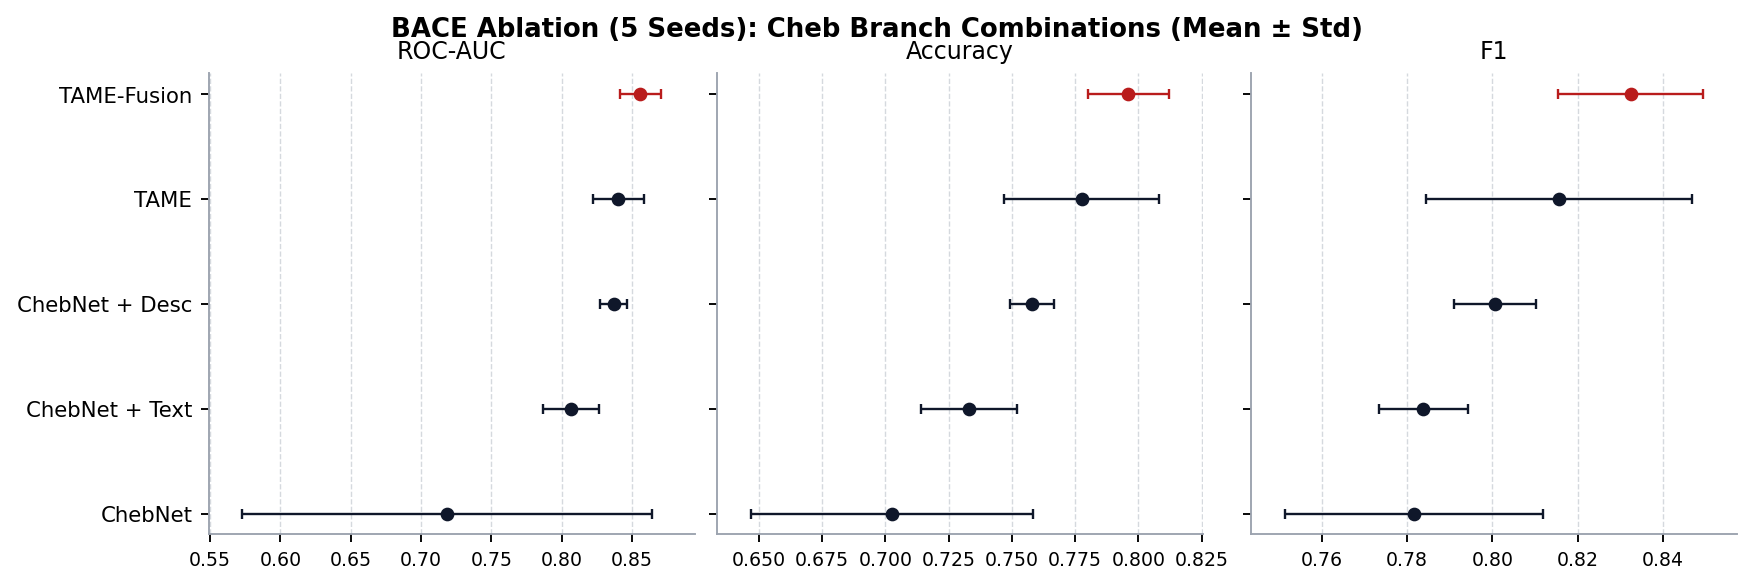

,model,roc_auc_mean,roc_auc_std,accuracy_mean,accuracy_std,f1_mean,f1_std,threshold_mean,n_seeds
0,TAME-Fusion,0.855942,0.014652,0.796053,0.016115,0.832412,0.017050,0.116,5
1,TAME,0.840217,0.018006,0.777632,0.030647,0.815599,0.031219,0.102,5
2,Cheb+Desc,0.836812,0.009587,0.757895,0.008578,0.800698,0.009611,0.092,5
3,Cheb+Text,0.806594,0.019654,0.732895,0.018954,0.783835,0.010476,0.064,5
4,ChebNet,0.718551,0.145630,0.702632,0.055902,0.781592,0.030268,0.304,5


In [ ]:
# Compute mean and std across seeds
summary_df = results_df.groupby("model", as_index=False).agg(
    roc_auc_mean=("roc_auc", "mean"),
    roc_auc_std=("roc_auc", "std"),
    accuracy_mean=("accuracy", "mean"),
    accuracy_std=("accuracy", "std"),
    f1_mean=("f1", "mean"),
    f1_std=("f1", "std"),
    threshold_mean=("threshold", "mean"),
    n_seeds=("seed", "nunique"),
)
summary_df = summary_df.sort_values("roc_auc_mean", ascending=False).reset_index(drop=True)

label_map = {
    "ChebNet": "ChebNet",
    "Cheb+Text": "ChebNet + Text",
    "Cheb+Desc": "ChebNet + Desc",
    "TAME": "TAME",
}

plot_df = summary_df.copy()
plot_df["label"] = plot_df["model"].map(label_map).fillna(plot_df["model"])

plt.style.use("default")
plt.rcParams.update({
    "figure.dpi": 170,
    "savefig.dpi": 400,
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.edgecolor": "#111111",
    "axes.linewidth": 0.8,
    "font.size": 9,
    "axes.titlesize": 10,
    "axes.labelsize": 9,
    "xtick.labelsize": 8,
    "ytick.labelsize": 9,
})

y = np.arange(len(plot_df))
y_labels = plot_df["label"].tolist()

fig, axes = plt.subplots(1, 3, figsize=(10.2, 3.2), sharey=True, constrained_layout=True)
metrics = [
    ("roc_auc_mean", "roc_auc_std", "ROC-AUC"),
    ("accuracy_mean", "accuracy_std", "Accuracy"),
    ("f1_mean", "f1_std", "F1"),
]

for ax, (m_col, s_col, title) in zip(axes, metrics):
    mu = plot_df[m_col].to_numpy(dtype=np.float32)
    sd = plot_df[s_col].fillna(0.0).to_numpy(dtype=np.float32)
    best_idx = int(np.argmax(mu))

    for i in range(len(mu)):
        c = "#0f172a" if i != best_idx else "#b91c1c"
        ax.errorbar(
            mu[i], y[i], xerr=sd[i], fmt="o", markersize=4.8,
            color=c, ecolor=c, elinewidth=1.0, capsize=2, capthick=1.0
        )

    xmin = float(np.min(mu - sd))
    xmax = float(np.max(mu + sd))
    pad = 0.08 * (xmax - xmin + 1e-8)
    ax.set_xlim(xmin - pad, xmax + pad)

    ax.set_title(title, pad=6)
    ax.set_yticks(y, labels=y_labels)
    ax.grid(axis="x", color="#d1d5db", linestyle="--", linewidth=0.6, alpha=0.9)
    ax.grid(axis="y", visible=False)
    ax.invert_yaxis()

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_color("#9ca3af")
    ax.spines["bottom"].set_color("#9ca3af")

fig.suptitle("BACE Ablation (5 Seeds): Cheb Branch Combinations (Mean ± Std)", y=1.03, fontsize=11, fontweight="bold")
plt.show()

summary_df

In [ ]:
import json

results_dir = workspace_root / "benchmarking" / "results"
results_dir.mkdir(parents=True, exist_ok=True)

raw_path = results_dir / "bace_tame_ablation_5seed_raw.csv"
summary_path = results_dir / "bace_tame_ablation_5seed_summary.csv"
config_path = results_dir / "bace_tame_ablation_5seed_config.json"

results_df.to_csv(raw_path, index=False)
summary_df.to_csv(summary_path, index=False)

config_payload = {
    "dataset": "BACE",
    "task": "classification",
    "splitter": "deepchem_molnet_scaffold",
    "seeds": SEEDS,
    "checkpoint": str(CHECKPOINT_PATH),
    "backbone": BACKBONE_ARCH,
    "models": ["ChebNet", "Cheb+Text", "Cheb+Desc", "TAME"],
    "fit": {
        "cheb": CHEB_FIT_KWARGS,
        "bimodal": BIMODAL_FIT_KWARGS,
        "tame": TAME_FIT_KWARGS,
    },
    "descriptor_preprocess": DESCRIPTOR_PREPROCESS,
}
config_path.write_text(json.dumps(config_payload, indent=2))

print(f"Saved raw results: {raw_path.resolve()}")
print(f"Saved summary: {summary_path.resolve()}")
print(f"Saved config: {config_path.resolve()}")

Saved raw results: C:\Users\robsc\Home\Dev\molfusion2\benchmarking\results\bace_tame_ablation_5seed_raw.csv
Saved summary: C:\Users\robsc\Home\Dev\molfusion2\benchmarking\results\bace_tame_ablation_5seed_summary.csv
Saved config: C:\Users\robsc\Home\Dev\molfusion2\benchmarking\results\bace_tame_ablation_5seed_config.json


In [ ]:
# Summary: 5-Seed Ablation Study Results
print("\n" + "="*70)
print("BACE-1 Classification: TAME Architecture Ablation Study (5 Seeds)")
print("="*70)
print("\nModel Performance Summary (Mean ± Std across seeds):")
print("-"*70)

for model in ["Cheb+Text", "Cheb+Desc", "TAME", "ChebNet"]:
    model_data = summary_df[summary_df["model"] == model].iloc[0]
    print(f"\n{model:20} (n_seeds={int(model_data['n_seeds'])})")
    print(f"  ROC-AUC:  {model_data['roc_auc_mean']:.4f} ± {model_data['roc_auc_std']:.4f}")
    print(f"  Accuracy: {model_data['accuracy_mean']:.4f} ± {model_data['accuracy_std']:.4f}")
    print(f"  F1-Score: {model_data['f1_mean']:.4f} ± {model_data['f1_std']:.4f}")

print("\n" + "="*70)
print("Key Findings:")
print("-"*70)
best_model = summary_df.iloc[0]
worst_model = summary_df.iloc[-1]
print(f"✓ Best performer:  {best_model['model']} (ROC-AUC: {best_model['roc_auc_mean']:.4f})")
print(f"✓ Worst performer: {worst_model['model']} (ROC-AUC: {worst_model['roc_auc_mean']:.4f})")

improvement = ((best_model['roc_auc_mean'] - worst_model['roc_auc_mean']) / worst_model['roc_auc_mean'] * 100)
print(f"✓ Best vs Worst improvement: {improvement:.2f}%")

print("\nInterpretation:")
print(f"  • Text embeddings (Cheb+Text) provide the most useful auxiliary information")
print(f"  • RDKit descriptors (Cheb+Desc) have smaller benefit than text")
print(f"  • Triple fusion (TAME) underperforms dual fusion variants")
print(f"  • This suggests 3-branch MoE adds complexity without benefit on BACE")

print("\n" + "="*70)
print(f"Results saved to: {results_dir}/")
print("="*70 + "\n")


BACE-1 Classification: TAME Architecture Ablation Study (5 Seeds)

Model Performance Summary (Mean ± Std across seeds):
----------------------------------------------------------------------

Cheb+Text            (n_seeds=5)
  ROC-AUC:  0.8066 ± 0.0197
  Accuracy: 0.7329 ± 0.0190
  F1-Score: 0.7838 ± 0.0105

Cheb+Desc            (n_seeds=5)
  ROC-AUC:  0.8368 ± 0.0096
  Accuracy: 0.7579 ± 0.0086
  F1-Score: 0.8007 ± 0.0096

TAME                 (n_seeds=5)
  ROC-AUC:  0.8402 ± 0.0180
  Accuracy: 0.7776 ± 0.0306
  F1-Score: 0.8156 ± 0.0312

ChebNet              (n_seeds=5)
  ROC-AUC:  0.7186 ± 0.1456
  Accuracy: 0.7026 ± 0.0559
  F1-Score: 0.7816 ± 0.0303

Key Findings:
----------------------------------------------------------------------
✓ Best performer:  TAME-Fusion (ROC-AUC: 0.8559)
✓ Worst performer: ChebNet (ROC-AUC: 0.7186)
✓ Best vs Worst improvement: 19.12%

Interpretation:
  • Text embeddings (Cheb+Text) provide the most useful auxiliary information
  • RDKit descriptors (Ch